# Setup

In [1]:
import re
import numpy as np

import tensorflow as tf

import matplotlib.pyplot as plt
from geexhp import datavis as dvis

dvis.configure_matplotlib()

2026-07-30 13:48:02.239541: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-30 13:48:02.240329: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-30 13:48:02.245505: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-30 13:48:02.259584: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785430082.284903  239167 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785430082.29

In [2]:
tfrecord_file = "../data/train.tfrecord"

# Reading TFRecords

In [3]:
# Parsing function
def parse_example(example_proto, feature_description):
    parsed_features = tf.io.parse_single_example(example_proto, feature_description)
    dense_features = {
        key: (
            tf.sparse.to_dense(value, default_value=0.0)
            if isinstance(value, tf.SparseTensor)
            else value
        )
        for key, value in parsed_features.items()
    }
    return dense_features

In [4]:
known_feature_description = {
    # "OBJECT-RADIUS-REL-EARTH": tf.io.FixedLenFeature([], tf.float32),
    # "OBJECT-GRAVITY": tf.io.FixedLenFeature([], tf.float32),
    # "ATMOSPHERE-TEMPERATURE": tf.io.FixedLenFeature([], tf.float32),
    # "ATMOSPHERE-PRESSURE": tf.io.FixedLenFeature([], tf.float32),
    # "C2H6": tf.io.FixedLenFeature([], tf.float32),
    "CH4": tf.io.FixedLenFeature([], tf.float32),
    # "CO": tf.io.FixedLenFeature([], tf.float32),
    "CO2": tf.io.FixedLenFeature([], tf.float32),
    "H2O": tf.io.FixedLenFeature([], tf.float32),
    "N2": tf.io.FixedLenFeature([], tf.float32),
    # "N2O": tf.io.FixedLenFeature([], tf.float32),
    "O2": tf.io.FixedLenFeature([], tf.float32),
    "O3": tf.io.FixedLenFeature([], tf.float32),
}

In [5]:
# Read TFRecord
dataset = tf.data.TFRecordDataset(tfrecord_file)
parsed_dataset = dataset.map(lambda x: parse_example(x, known_feature_description))

2026-07-30 13:48:19.746177: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Get best $n$ values (Hellinger Transform)

In [6]:
# Get samples from dataset
samples = []
for batch in parsed_dataset:
    samples.append(batch)

2026-07-30 13:48:22.096122: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-07-30 13:48:35.132775: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
# Extracting values from samples into a dictionary
result = {key: [d[key] for d in samples] for key in samples[0]}

In [8]:
# Extracting values from the result dictionary into numpy arrays for each molecule
molecules = {
    # 'C2H6' : np.array([float(value.numpy()) for value in result['C2H6']]),
    "CH4": np.array([float(value.numpy()) for value in result["CH4"]]),
    # 'CO' : np.array([float(value.numpy()) for value in result['CO']]),
    "CO2": np.array([float(value.numpy()) for value in result["CO2"]]),
    "H2O": np.array([float(value.numpy()) for value in result["H2O"]]),
    "N2": np.array([float(value.numpy()) for value in result["N2"]]),
    # 'N2O' : np.array([float(value.numpy()) for value in result['N2O']]),
    "O2": np.array([float(value.numpy()) for value in result["O2"]]),
    "O3": np.array([float(value.numpy()) for value in result["O3"]]),
}

## Molecules

In [9]:
def interval_hist_molecules(
    molecule, n_start=1, n_end=20, divs=1000, bins=200, plot=True
):
    n_values = np.linspace(n_start, n_end, divs)

    area_array = []
    intervals = []

    for n_value in n_values:
        if n_value == 0.0:
            continue

        data = np.power(molecules[molecule], (1 / n_value))

        counts, bin_edges = np.histogram(data, bins=bins)

        valids = np.nonzero(counts)[0]
        interval = 0
        for i in valids:
            interval += bin_edges[i + 1] - bin_edges[i]
        intervals.append(interval)

        area = np.sum(counts * np.diff(bin_edges))
        area_array.append(area)

    max_index = np.argmax(intervals)

    plt.plot(n_values, intervals, color="tab:gray")
    plt.title(f"Histogram data interval with {bins} bins for {molecule}")

    plt.scatter(
        n_values[max_index],
        intervals[max_index],
        color="k",
        label=f"Maximum interval value \n n = {n_values[max_index]:.4f} \n interval = {intervals[max_index]:.4f} \n area = {area_array[max_index]:.4f}",
    )
    plt.vlines(
        n_values[max_index],
        min(intervals),
        max(intervals),
        linestyles="dashed",
        color="tab:red",
    )
    plt.hlines(
        max(intervals),
        min(n_values),
        n_values[max_index],
        linestyles="dashed",
        color="tab:red",
    )

    plt.xlim((min(n_values), max(n_values)))
    plt.ylim((min(intervals), max(intervals) * 1.02))

    plt.xlabel(r"$n$ value")
    plt.ylabel(r"Data Interval")

    plt.legend(loc="lower right")
    plt.show()

    return n_values[max_index]

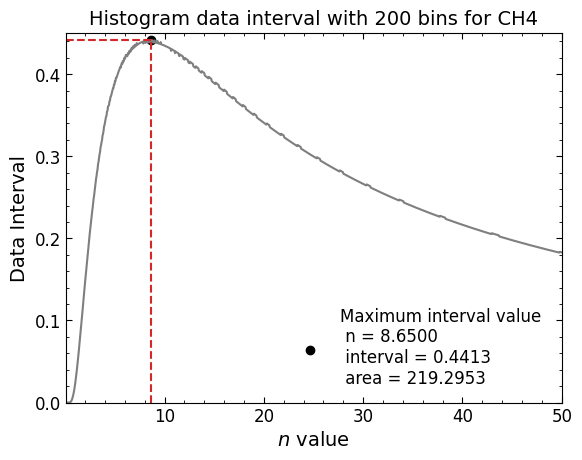

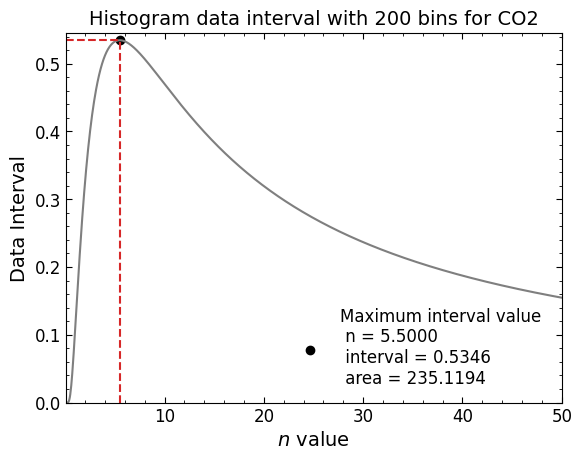

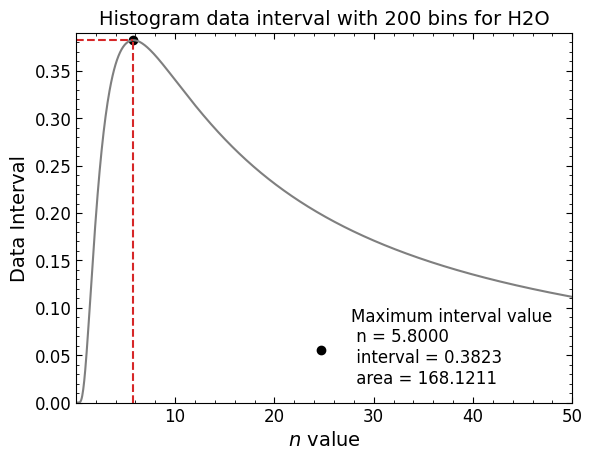

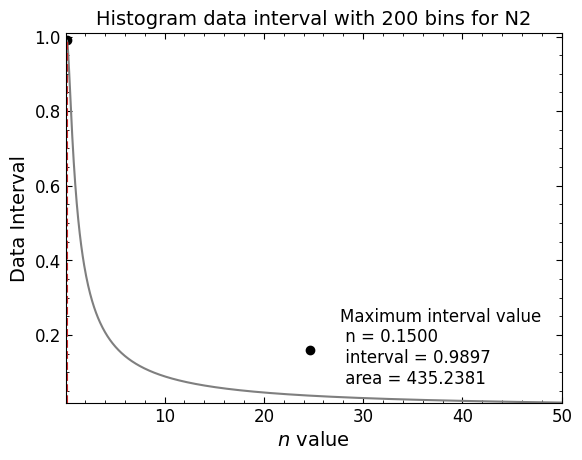

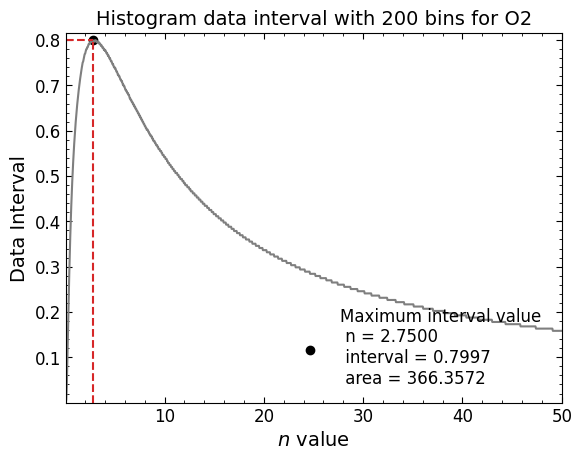

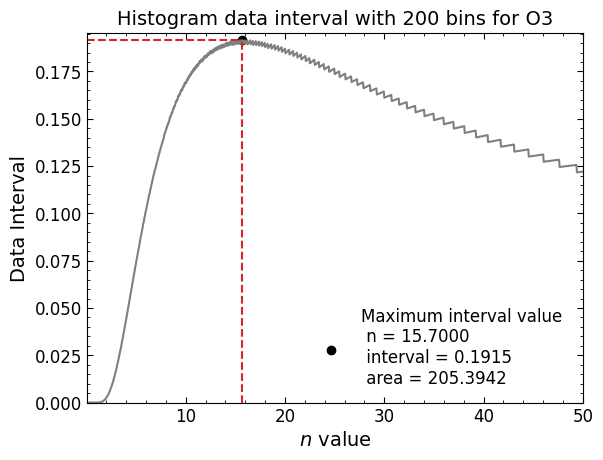

In [10]:
best_n_values = {}

for mol_key in list(molecules.keys()):
    best_n_values[mol_key] = interval_hist_molecules(mol_key, n_start=0.05, n_end=50)

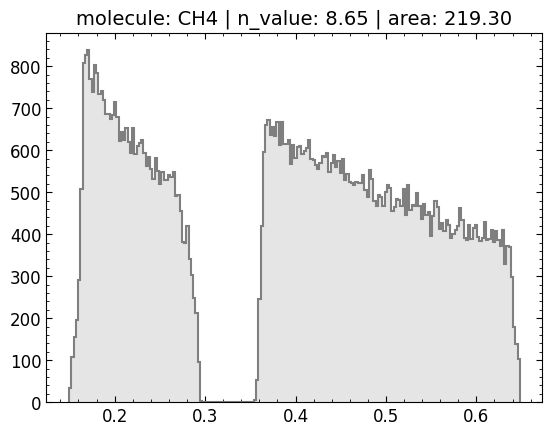

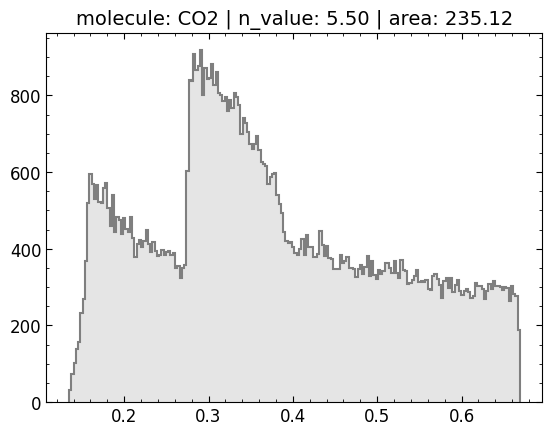

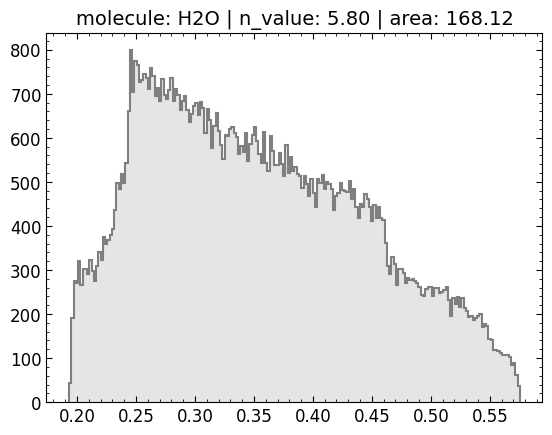

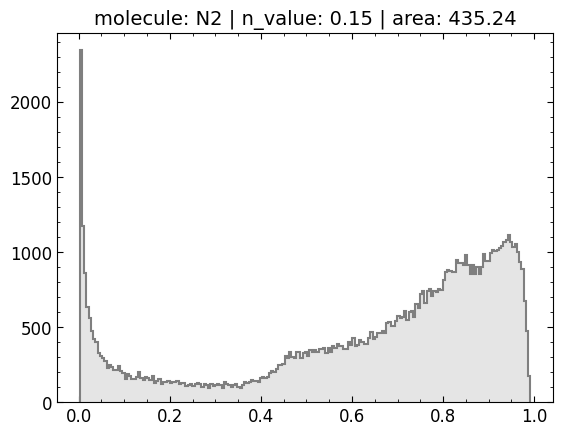

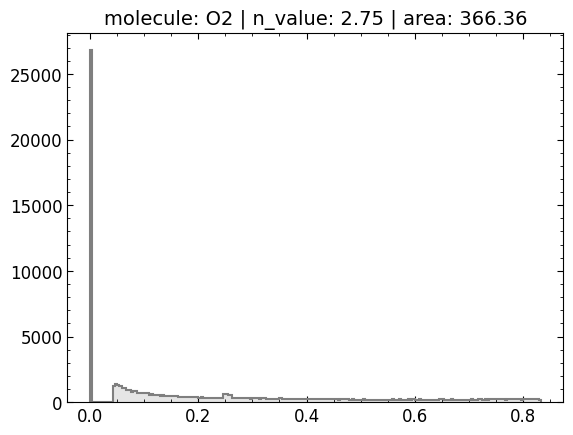

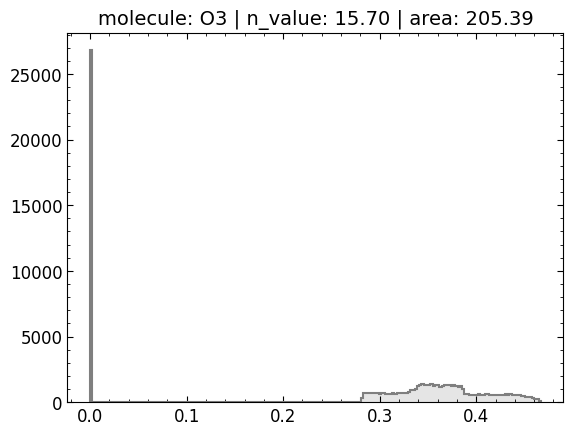

In [11]:
# Let's plot the histograms for each molecule using the best n value
bins = 200

for i, molecule in enumerate(list(molecules.keys())):
    data = np.power(molecules[molecule], (1 / best_n_values[molecule]))
    counts, bin_edges = np.histogram(data, bins=bins)
    area = np.sum(counts * np.diff(bin_edges))

    plt.hist(data, bins=bins, histtype="step", color="tab:gray", lw=1.5)
    plt.hist(data, bins=bins, color="tab:gray", alpha=0.2)
    plt.title(
        f"molecule: {molecule} | n_value: {best_n_values[molecule]:.2f} | area: {area:.2f}"
    )
    # plt.ylim((0, 2000))
    plt.show()

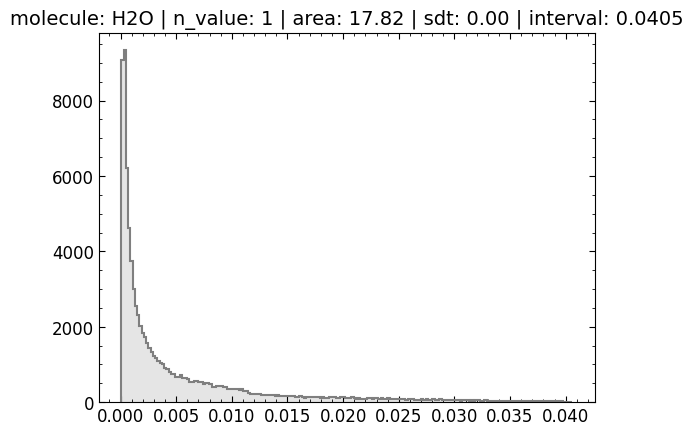

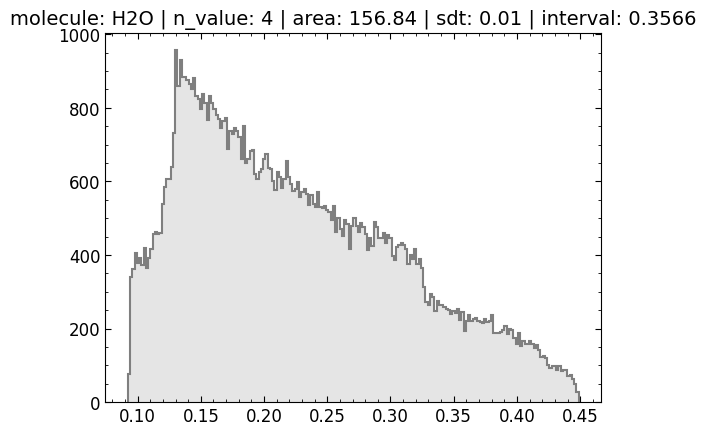

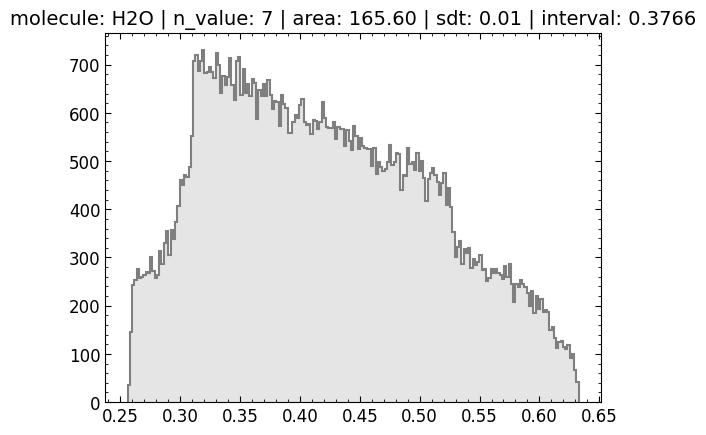

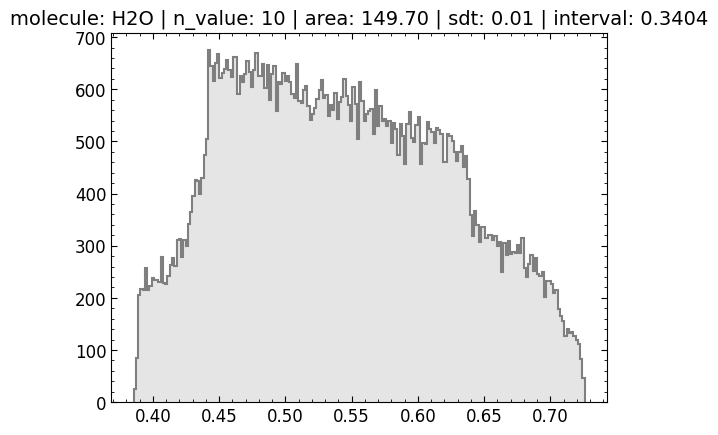

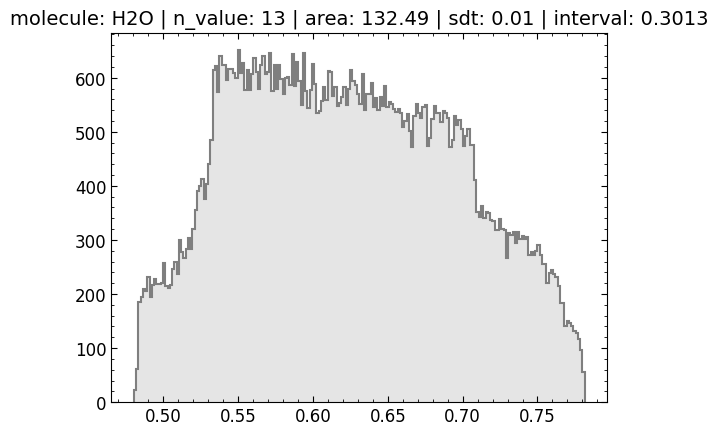

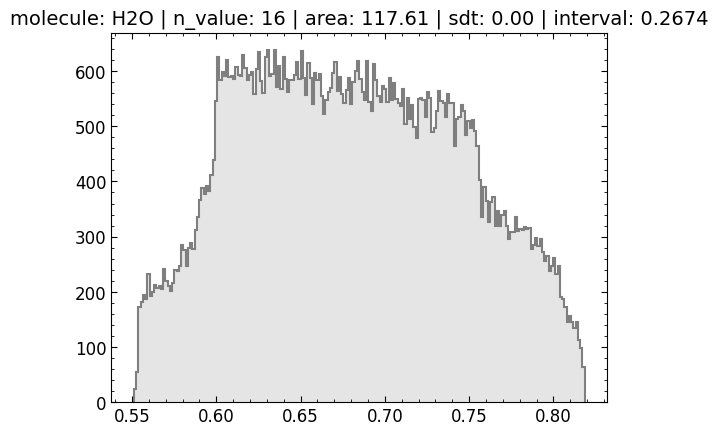

In [12]:
# Let's see how a power transformation with different n values affects
# the histogram of the H2O molecule
n_values = np.arange(1, 17, 3)
molecule = "H2O"
bins = 200

for n_value in n_values:
    data = np.power(molecules[molecule], (1 / n_value))
    counts, bin_edges = np.histogram(data, bins=bins)

    valids = np.nonzero(counts)[0]
    interval = 0
    for i in valids:
        interval += bin_edges[i + 1] - bin_edges[i]

    area = np.sum(counts * np.diff(bin_edges))

    spread_std = np.std(data) ** 2
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    plt.hist(data, bins=bins, histtype="step", color="tab:gray", lw=1.5)
    plt.hist(data, bins=bins, color="tab:gray", alpha=0.2)
    plt.title(
        f"molecule: {molecule} | n_value: {n_value} | area: {area:.2f} | sdt: {spread_std:.2f} | interval: {interval:.4f}"
    )
    # plt.ylim((0, 2000))
    plt.show()

In [13]:
best_n_values

{'CH4': np.float64(8.65),
 'CO2': np.float64(5.5),
 'H2O': np.float64(5.8),
 'N2': np.float64(0.15000000000000002),
 'O2': np.float64(2.75),
 'O3': np.float64(15.700000000000001)}

In [13]:
best_n_values

{'CH4': np.float64(6.75),
 'CO2': np.float64(3.7),
 'H2O': np.float64(5.6000000000000005),
 'N2': np.float64(0.4),
 'O2': np.float64(2.35),
 'O3': np.float64(13.750000000000002)}

The function examines how a power transformation affects the data's distribution. For each $ n $ in a specified range, it transforms the original data $ x $ using the relation $ y = x^{\frac{1}{n}} $, thereby altering its distribution. It then computes a histogram of the transformed data by dividing it into a fixed number of bins. From the histogram, two key quantities are calculated: an "interval" and an "area." The interval is defined as the sum of the widths of all bins that contain at least one data point, which can be mathematically expressed as

$$
\text{Interval}(n) = \sum_{i: \text{count}_i > 0} (b_{i+1} - b_i),
$$

where $ b_i $ are the bin edges and $\text{count}_i$ are the counts in each bin. In parallel, the area under the histogram is computed as

$$
\text{Area}(n) = \sum_{i} \text{count}_i \cdot (b_{i+1} - b_i),
$$

which represents a Riemann sum approximation of the integral of the histogram. This area essentially approximates the total "weight" or cumulative frequency of the data across its range. The function then identifies the value of $ n $ that maximizes the interval, meaning that the transformed data achieves the widest spread or support. This optimal $ n $ is both highlighted in the plot and returned, providing a parameter choice that best reveals the underlying structure of the data.

# Plotting the figures to the paper

In [14]:
def hist_interval(data_array, n_start=1, n_end=20, divs=1000, bins=200):
    # The same function of interval_hist_molecules but for a unique data array
    n_values = np.linspace(n_start, n_end, divs)

    area_array = []
    intervals = []

    for n_value in n_values:
        if n_value == 0.0:
            continue

        data = np.power(data_array, (1 / n_value))

        counts, bin_edges = np.histogram(data, bins=bins)

        valids = np.nonzero(counts)[0]
        interval = 0
        for i in valids:
            interval += bin_edges[i + 1] - bin_edges[i]
        intervals.append(float(interval))

        area = np.sum(counts * np.diff(bin_edges))
        area_array.append(area)

    return n_values, np.array(intervals)

In [15]:
import matplotlib.ticker as mticker

In [16]:
def _kM_no_trailing_decimal(x, pos=None):
    x = float(x)
    if abs(x) < 1000:
        return f"{int(round(x))}"
    if abs(x) < 1_000_000:
        v = x / 1000.0
        s = f"{v:.1f}".rstrip("0").rstrip(".")
        return f"{s}k"
    v = x / 1_000_000.0
    s = f"{v:.1f}".rstrip("0").rstrip(".")
    return f"{s}M"

In [17]:
def format_molecule(molecule):
    return re.sub(r"(\d+)", r"$_{\1}$", molecule)


def plt_n_inspection_species(species_dict, save=False):
    n_species = len(species_dict)
    bins = 100

    _, axs = plt.subplots(n_species, 3, figsize=(9, 10))

    if n_species == 1:
        axs = np.array([axs])

    for idx, (molecule, sp_info) in enumerate(species_dict.items()):
        data = sp_info["data"]
        best_n = sp_info["best_n"]

        # Format molecule notation for display
        molecule_label = format_molecule(molecule)

        # Analyse histogram interval over a range of n values.
        n_values, intervals = hist_interval(data, n_start=0.05, n_end=50)
        max_index = np.argmax(intervals)

        # Plot 1: Original Data Histogram
        ax = axs[idx, 0]
        ax.hist(data, bins=bins, color="k", histtype="step")
        ax.hist(data, bins=bins, color="k", alpha=0.8)
        ax.set_title(f"{molecule_label} - Original data")
        ax.set_xlabel("Raw data value")
        ax.set_ylabel("Counts")
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(_kM_no_trailing_decimal))

        # Plot 2: Histogram Interval Analysis
        ax = axs[idx, 1]
        ax.plot(n_values, intervals, color="k")
        ax.scatter(
            n_values[max_index], intervals[max_index], color="tab:red", edgecolor="k"
        )
        ax.vlines(
            n_values[max_index],
            min(intervals),
            max(intervals),
            linestyles="dashed",
            color="tab:red",
        )
        ax.hlines(
            max(intervals),
            min(n_values),
            n_values[max_index],
            linestyles="dashed",
            color="tab:red",
        )
        ax.set_xlim((min(n_values), max(n_values)))
        ax.set_ylim((min(intervals), max(intervals) * 1.02))
        ax.set_title(f"{molecule_label} - Histogram interval")
        ax.set_xlabel("$n$ value")
        ax.set_ylabel("Valid interval width")
        # ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
        # ax.ticklabel_format(axis="x", style="sci")
        # ax.yaxis.set_major_formatter(mticker.FuncFormatter(_kM_no_trailing_decimal))
        ax.text(15, 0.1, f"max $n$ = {n_values[max_index]:.2f}", fontsize=11)
        # ax.legend()

        # Plot 3: Transformed Data Histogram
        ax = axs[idx, 2]
        transformed_data = np.power(data, 1 / best_n)
        ax.hist(transformed_data, bins=bins, color="k", histtype="step")
        ax.hist(transformed_data, bins=bins, color="tab:gray", alpha=0.2)
        ax.set_title(f"{molecule_label} - Transformed data")
        ax.set_xlabel("Transformed data value")
        ax.set_ylabel("Counts")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(_kM_no_trailing_decimal))
        # ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=False)

    # plt.tight_layout()
    plt.subplots_adjust(wspace=0.4, hspace=0.6)
    if save:
        plt.savefig(save, dpi=300, bbox_inches="tight")
    plt.show()

In [18]:
species = {
    "CH4": {"data": molecules["CH4"], "best_n": 6.75},
    # 'CO': {'data': molecules['CO'], 'best_n': 6.8},
    # 'CO2' : {'data': molecules['CO2'], 'best_n': 3.65},
    # 'H2O' : {'data': molecules['H2O'], 'best_n': 4.8},
    "N2": {"data": molecules["N2"], "best_n": 0.40},
    # 'N2O' : {'data': molecules['N2O'], 'best_n': 16.15},
    # 'O2' : {'data': molecules['O2'], 'best_n': 2.35},
    "O3": {"data": molecules["O3"], "best_n": 13.75},
}

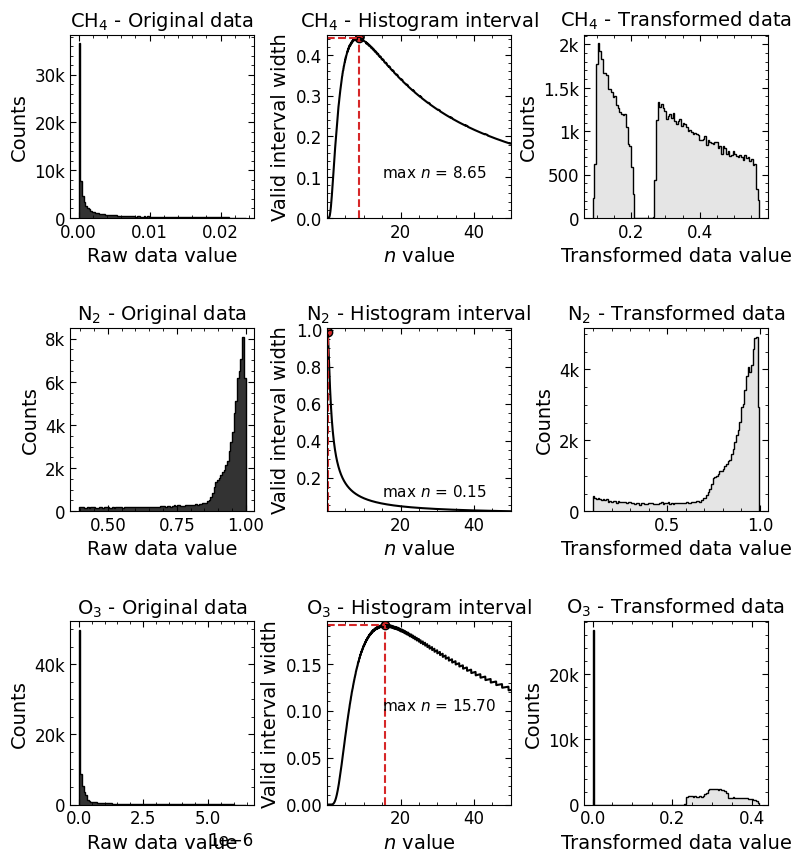

In [19]:
plt_n_inspection_species(species)

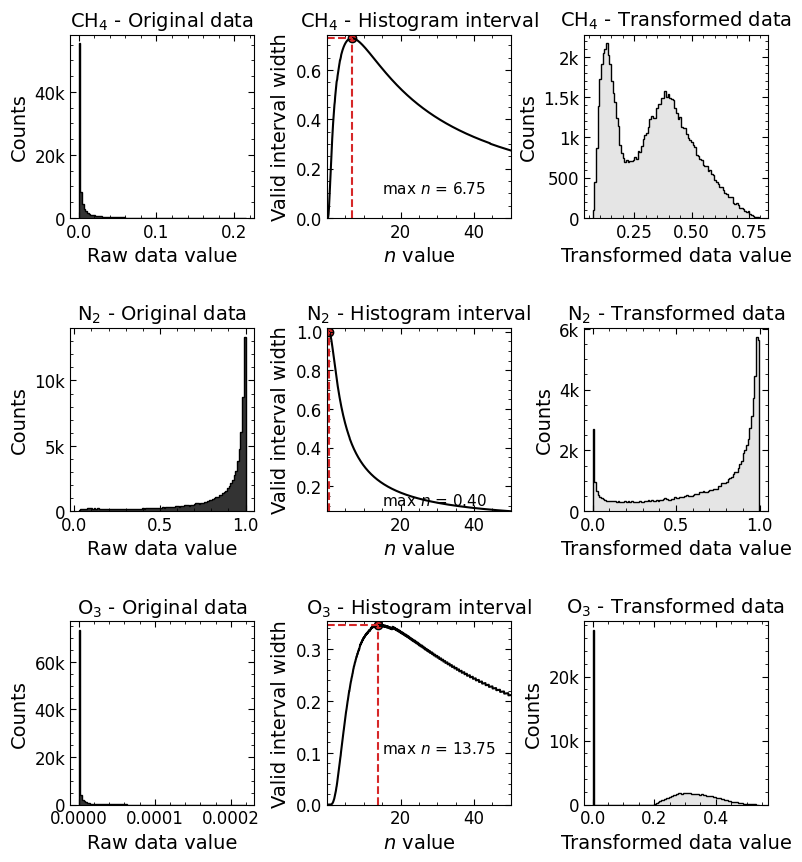

In [62]:
plt_n_inspection_species(species, save="../images/selected_species_n_value.pdf")